In [1]:
#rename file
import os
import glob
from astropy.io import fits
import numpy as np
from astropy.visualization import simple_norm
import matplotlib.pyplot as plt
from scipy.optimize import leastsq
from scipy.optimize import fsolve
from scipy.optimize import minimize
import os
import re
from astropy.table import Table
import astropy.units as u
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from photutils.aperture import SkyCircularAperture, SkyCircularAnnulus
from photutils.aperture import aperture_photometry
from photutils.centroids import centroid_com
from astropy.stats import sigma_clipped_stats
from astropy.visualization import simple_norm
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import time

from collections import OrderedDict

from scipy.integrate import cumtrapz

import eazy
import eazy.hdf5

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy import wcs
from astropy.table import Table, vstack
from astropy.io import fits
from astropy.visualization import (MinMaxInterval, SqrtStretch, ImageNormalize)
from astropy.visualization.mpl_normalize import simple_norm
from astropy.visualization import ZScaleInterval
from astropy.nddata import Cutout2D, NDData
from astropy.wcs import WCS

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe



import warnings
warnings.filterwarnings('ignore')

def magerr2snr(magerr):
    nsr = 10**(magerr / 2.5) - 1
    return 1 / nsr

def snr2magerr(snr):
    magerr = 2.5 * np.log10(1 + 1/snr)
    return magerr

 
plt.style.use('/Users/zijianzhang/Astro_Data/paper.mplstyle')

Failed to `import dust_attenuation`
Install from the repo with $ pip install git+https://github.com/karllark/dust_attenuation.git


Duplicate key in file '/Users/zijianzhang/Astro_Data/paper.mplstyle', line 23 ('axes.linewidth : 1.5')


In [2]:
import h5py

h5file = '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/EAZY_v01/RXCJ2211-0350_v01_CIRC1.eazy.h5'

with h5py.File(h5file, 'r+') as f:
    fit_attrs = f['fit'].attrs
    
    # 修改模板路径为当前环境的实际路径
    fit_attrs['TEMPLATES_FILE'] = (
        '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/EAZY_v01/templates/template_Hainline/template_Hainline.param'
    )
    fit_attrs['TEMP_ERR_FILE'] = (
        '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/EAZY_v01/templates/TEMPLATE_ERROR.v2.0.zfourge'
    )
    fit_attrs['FILTERS_RES'] = (
        '/Users/zijianzhang/Documents/Git/magnif_eazy-main/eazy-photoz-master/filters/FILTER.RES.latest'
    )

    print("✅ 已更新模板、误差文件与滤波器路径")

✅ 已更新模板、误差文件与滤波器路径


In [3]:
eazy_hdf5 = '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/EAZY_v01/RXCJ2211-0350_v01_CIRC1.eazy.h5'
ez = eazy.hdf5.initialize_from_hdf5(eazy_hdf5)

Read default param file: /Users/zijianzhang/miniconda3/envs/msaexp39/lib/python3.9/site-packages/eazy/data/zphot.param.default
CATALOG_FILE is a table
   >>> NOBJ = 7739
f_F090W e_F090W (363): jwst_nircam_f090w
f_F115W e_F115W (364): jwst_nircam_f115w
f_F150W e_F150W (365): jwst_nircam_f150w
f_F200W e_F200W (366): jwst_nircam_f200w
f_F210M e_F210M (371): jwst_nircam_f210m
f_F277W e_F277W (375): jwst_nircam_f277w
f_F300M e_F300M (380): jwst_nircam_f300m
f_F356W e_F356W (376): jwst_nircam_f356w
f_F410M e_F410M (383): jwst_nircam_f410m
f_F444W e_F444W (377): jwst_nircam_f444w
Set sys_err = 0.00 (positive=True)
Template grid: /Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/EAZY_v01/templates/template_Hainline/template_Hainline.param (this may take some time)
TemplateGrid: user-provided tempfilt_data
Process templates: 0.102 s


343it [00:00, 1996.96it/s]


h5: read eazy_v1.1_sed4.sed
h5: read eazy_v1.1_sed3.sed
h5: read eazy_v1.1_sed1.sed
h5: read eazy_v1.1_sed2.sed
h5: read eazy_v1.1_sed6.sed
h5: read erb2010_highEW.sed
h5: read c09_del_8.6_z_0.019_chab_age09.40_av2.0.sed
h5: read eazy_v1.1_sed7.sed
h5: read JADES_v1.0_1.sed
h5: read JADES_v1.0_2.sed
h5: read JADES_v1.0_6.sed
h5: read JADES_v1.0_4.sed
h5: read JADES_v1.0_5.sed
h5: read JADES_v1.0_7.sed
h5: read JADES_v1.0_3.sed
h5: read eazy_v1.1_sed5.sed
fit_best: 1.6 s (n_proc=1,  NOBJ=7645)


In [4]:
tab_cat = Table.read('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/EAZY_v01/multiimg_CIRC1.eazy.fits')
contamination = [4.1, 4.5, 11.3, 11.4, 11.5, 11.6, 17.3, 18.1, 18.2, 18.3, 18.4, 19.1, 19.2, 19.3, 21.3, 26.1, 26.2, 29.1, 29.2, 29.4, 36.1, 36.2,36.3, 36.4]
contamination = np.array([str(i) for i in contamination ])
contamination_mask = np.array([str(i) in contamination for i in tab_cat['id_1']])
tab_cat= tab_cat[(~contamination_mask) ]

In [5]:
tab_cat

id_1,ra_1,dec_1,z_lensing,mu_best,mu_tan_best,mu_rad_best,theta_best,deflect_x_best,deflect_y_best,ra_source_best,dec_source_best,mu_50,mu_16,mu_84,mu_rad_50,mu_rad_16,mu_rad_84,mu_tan_50,mu_tan_16,mu_tan_84,theta_50,theta_16,theta_84,deflect_x_50,deflect_y_50,deflect_x_16,deflect_y_16,deflect_x_84,deflect_y_84,ra_source_50,dec_source_50,ra_source_16,dec_source_16,ra_source_84,dec_source_84,id_2,RA_2,DEC_2,f_F090W,e_F090W,f_F115W,e_F115W,f_F150W2,e_F150W2,f_F150W,e_F150W,f_F200W,e_F200W,f_F210M,e_F210M,f_F277W,e_F277W,f_F300M,e_F300M,f_F322W2,e_F322W2,f_F356W,e_F356W,f_F410M,e_F410M,f_F444W,e_F444W,Separation
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,arcsec
float32,float64,float64,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int16,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1.1,332.9399962,-3.8241159,1.051,3.2423495548579555,-1.7747825147907372,1.8268996498651315,79.49155074921998,7.133426888614571,18.055332521230554,332.94198212916996,-3.829131270144786,3.204350323683509,3.070536972872839,3.34543064994603,1.8821257621925231,1.829849319476777,1.9932870610973148,-1.6820880100977278,-1.757345395222756,-1.609064149235015,79.2467418506333,78.76709466144065,79.7904167575347,7.50964768785324,18.414851245561195,7.254123235832441,18.118752272508694,7.725524788657912,18.65370538762448,332.9420868681504,-3.8292311364571003,332.94201573074747,-3.8292974848298953,332.94214696782456,-3.8291488867423635,6771,332.9399841854516,-3.8241308959765217,458.84562061932155,22.94228103096608,545.0319514786322,27.251597573931612,630.637704871406,31.5318852435703,645.6321942423446,32.28160971211723,759.4088540526302,37.97044270263151,767.6843351169632,38.384216755848165,904.8005692515372,45.240028462576866,902.5975495617994,45.12987747808997,938.5121049059553,46.92560524529777,977.4290326453382,48.87145163226691,886.218605634522,44.3109302817261,843.9765432446209,42.19882716223105,0.06911499417197296
1.2,332.9330212,-3.8288937,1.051,4.248419758501714,2.8859873357019317,1.4720853781807781,179.16591832125516,32.20299685663842,0.7609961920568922,332.9419864881437,-3.829105087831127,4.135055547219374,4.03433830108376,4.246936388697442,1.4365128141238412,1.4130832076140156,1.4610950756853343,2.886633254703354,2.8441906097984306,2.92343646297033,178.82976016151378,178.1116993478436,179.37611793535947,32.87035625814252,0.8359181227981015,32.40723850437224,0.6405968272342708,33.17738840416183,1.0623780576920558,332.9421722804585,-3.829125899478555,332.9420433488524,-3.8291888050160257,332.9422577579584,-3.829071643563121,6705,332.9330220703726,-3.828903771837506,446.82078472451366,22.341039236225683,536.681937080544,26.8340968540272,640.1681234168012,32.00840617084006,633.4629075787894,31.673145378939473,741.3308341145724,37.066541705728625,765.4396495753037,38.27198247876519,935.4439014946927,46.77219507473464,932.4163300190452,46.62081650095226,974.71015226493,48.735507613246504,1003.7577193209612,50.187885966048064,936.6977476976754,46.83488738488377,872.1621987444713,43.60810993722357,0.036393147859235024
1.3,332.9384753,-3.834327,1.051,2.941819174814258,-1.7966253622970445,1.6374138073243303,112.97463782736602,13.174102712351653,-18.380134850482925,332.9421429827782,-3.829221406985977,2.784767768855504,2.687101697411997,2.9165128140828136,1.616612856596592,1.5904539413951542,1.6408438341460487,-1.7265671274428778,-1.7856508677280623,-1.6804109221449517,112.8111314587957,112.47219439554478,113.12067257877807,13.711294175517203,-18.561642109894702,13.356098713242014,-18.81600938064629,14.012547558102323,-18.405950631829782,332.9422925373946,-3.829170988

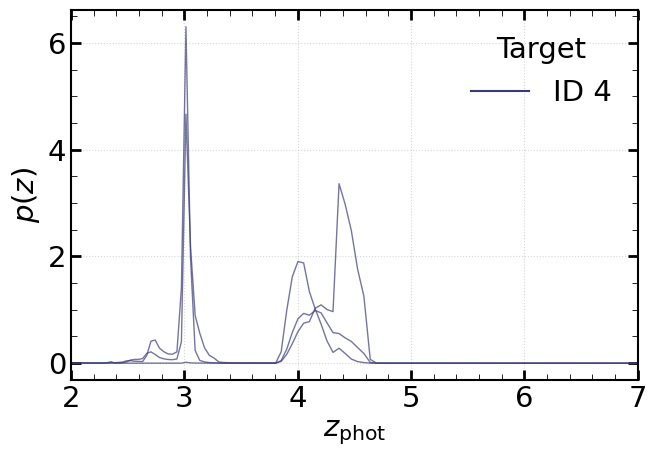

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# targetlist = ['4.', '11.', '16.', '17.', '18.', '22.', '37.']
targetlist = ['4.']
names = tab_cat['id_1']

# 配色（同一个target同一种颜色）
colors = plt.cm.tab20b(np.linspace(0, 1, len(targetlist)))

plt.figure(figsize=(7, 5))

for target, color in zip(targetlist, colors):
    # 用 float 范围筛选属于同一个 target 的所有 image
    namemask = (names >= float(target)) & (names < float(target) + 1)
    dfsub = tab_cat[namemask]

    # 累积该 target 所有 image 的 phot-z 概率曲线
    for id in dfsub['id_2']:
        # 确保 ID 存在于 EAZY catalog
        match = np.where(ez.cat['id'] == id)[0]
        if len(match) == 0:
            continue

        ez_idx = match[0]
        pz = np.exp(ez.lnp[ez_idx])
        # pz /= pz.max()  # 归一化，便于比较
        plt.plot(ez.zgrid, pz, lw=1.0, alpha=0.7, color=color)

# 坐标和样式
plt.xlim(2, 7)
# plt.ylim(0, 1.1)
plt.xlabel(r'$z_{\mathrm{phot}}$')
plt.ylabel(r'$p(z)$')
plt.grid(ls=':', alpha=0.5)

# 图例（每个 target 只显示一次）
for target, color in zip(targetlist, colors):
    plt.plot([], [], color=color, label=f'ID {target[:-1]}')
plt.legend(frameon=False, title='Target')

plt.tight_layout()
plt.show()

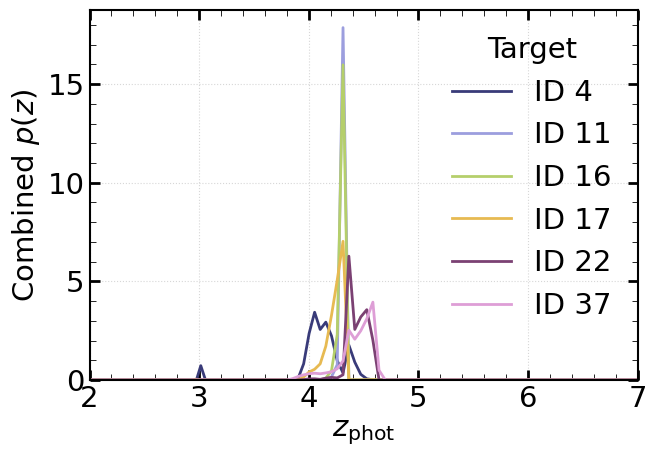

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# targetlist = ['4.', '9.', '10.', '11.', '16.', '17.', '18.', '22.', '37.']
targetlist = ['4.', '11.', '16.', '17.', '18.', '22.', '37.']
names = tab_cat['id_1']
colors = plt.cm.tab20b(np.linspace(0, 1, len(targetlist)))

plt.figure(figsize=(7, 5))

for target, color in zip(targetlist, colors):
    namemask = (names >= float(target)) & (names < float(target) + 1)
    dfsub = tab_cat[namemask]

    chi2_sum = None

    for id in dfsub['id_2']:
        match = np.where(ez.cat['id'] == id)[0]
        if len(match) == 0:
            continue
        chi2_i = ez.chi2_fit[match[0], :]

        if chi2_sum is None:
            chi2_sum = chi2_i.copy()
        else:
            chi2_sum += chi2_i  # 累积 χ²

    if chi2_sum is None:
        continue

    # 转为联合概率分布
    pz_combined = np.exp(-0.5 * (chi2_sum - np.nanmin(chi2_sum)))
    pz_combined /= np.trapz(pz_combined, ez.zgrid)

    plt.plot(ez.zgrid, pz_combined, color=color, lw=2,
             label=f'ID {target[:-1]}')

plt.xlim(2, 7)
plt.ylim(0, None)
plt.xlabel(r'$z_{\mathrm{phot}}$')
plt.ylabel(r'Combined $p(z)$')
plt.legend(frameon=False, title='Target')
plt.grid(ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

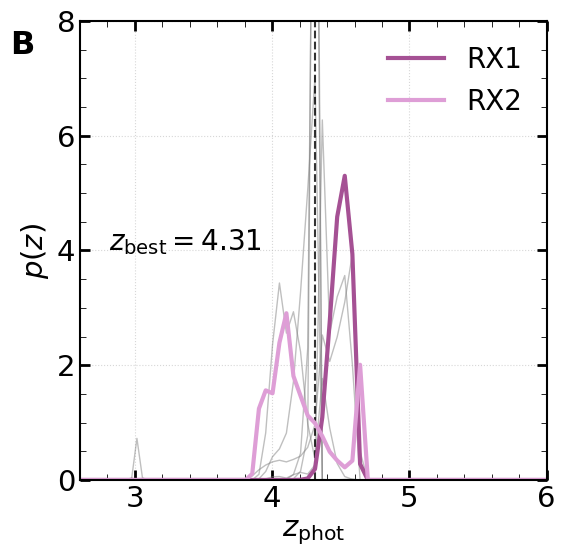

In [9]:
chi2_all = None  # 全部源的联合 chi²

plt.figure(figsize=(6, 6))
targetlist = ['4.', '11.', '16.', '17.', '18.', '22.', '37.']
colors = plt.cm.tab20b(np.linspace(0, 1, len(targetlist )+ 2))


for target, color in zip(targetlist, colors):
    namemask = (names >= float(target)) & (names < float(target) + 1)
    dfsub = tab_cat[namemask]
    color = 'gray'
    chi2_sum = None

    for id in dfsub['id_2']:
        match = np.where(ez.cat['id'] == id)[0]
        if len(match) == 0:
            continue
        chi2_i = ez.chi2_fit[match[0], :]

        if chi2_sum is None:
            chi2_sum = chi2_i.copy()
        else:
            chi2_sum += chi2_i

    if chi2_sum is None:
        continue

    # 累加到全局 χ²
    if chi2_all is None:
        chi2_all = chi2_sum.copy()
    else:
        chi2_all += chi2_sum

    # 各源的联合 p(z)
    pz_combined = np.exp(-0.5 * (chi2_sum - np.nanmin(chi2_sum)))
    pz_combined /= np.trapz(pz_combined, ez.zgrid)
    plt.plot(ez.zgrid, pz_combined, color=color, lw=1, alpha = 0.5)#label=f'ID {target[:-1]}')

# ===== 所有源的联合 p(z) =====
pz_all = np.exp(-0.5 * (chi2_all - np.nanmin(chi2_all)))
pz_all /= np.trapz(pz_all, ez.zgrid)

# 找峰值红移
z_best_all = ez.zgrid[np.argmax(pz_all)]



# 红线：总体联合分布
# plt.plot(ez.zgrid, pz_all, 'r-', lw=1, label='All combined')
plt.axvline(z_best_all, color='black', ls='--', lw=1.5, alpha=0.8)
plt.text(z_best_all-1.5, 4,
         fr'$z_{{\rm best}}={z_best_all:.2f}$', color='k', fontsize=20)

pz_RX1 = np.loadtxt('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/eazy_pz_RX1.txt', delimiter=',').T
plt.plot(pz_RX1[0], pz_RX1[1], color=colors[-2], lw=3, label = 'RX1')
pz_RX2 = np.loadtxt('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/eazy_pz_RX2.txt', delimiter=',').T
plt.plot(pz_RX2[0], pz_RX2[1], color=colors[-1], lw=3, label = 'RX2')
# 样式
plt.xlim(2.6, 6)
plt.ylim(0, 8)
plt.xlabel(r'$z_{\mathrm{phot}}$')
plt.ylabel(r'$p(z)$')
plt.legend(frameon=False, fontsize = 20)
plt.grid(ls=':', alpha=0.5)
plt.tight_layout()
plt.text(-0.15, 0.98, f'B', color='k', fontsize=23, transform=plt.gca().transAxes, ha='left', va='top', weight='bold')
# plt.show()
plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'z4source_photz.pdf', dpi=200, bbox_inches='tight')

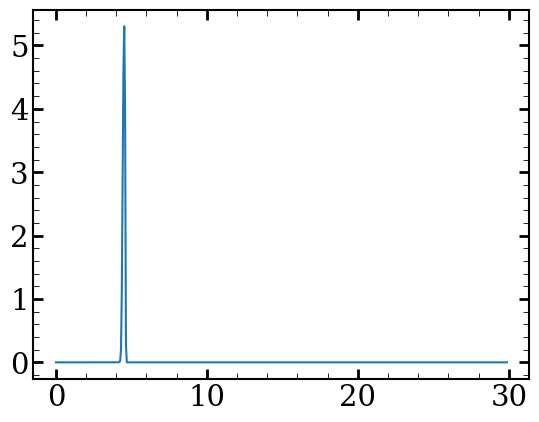

In [29]:
pz_RX1

array([[9.99999978e-03, 2.01506689e-02, 3.04033533e-02, 4.07590792e-02,
        5.12188822e-02, 6.17838055e-02, 7.24549145e-02, 8.32332596e-02,
        9.41199362e-02, 1.05116025e-01, 1.16222627e-01, 1.27440855e-01,
        1.38771817e-01, 1.50216669e-01, 1.61776543e-01, 1.73452586e-01,
        1.85245976e-01, 1.97157905e-01, 2.09189534e-01, 2.21342087e-01,
        2.33616784e-01, 2.46014833e-01, 2.58537501e-01, 2.71186024e-01,
        2.83961654e-01, 2.96865672e-01, 3.09899390e-01, 3.23064089e-01,
        3.36361110e-01, 3.49791765e-01, 3.63357395e-01, 3.77059370e-01,
        3.90899032e-01, 4.04877812e-01, 4.18997079e-01, 4.33258235e-01,
        4.47662711e-01, 4.62211967e-01, 4.76907432e-01, 4.91750598e-01,
        5.06742954e-01, 5.21885991e-01, 5.37181199e-01, 5.52630126e-01,
        5.68234265e-01, 5.83995283e-01, 5.99914730e-01, 6.15994155e-01,
        6.32235169e-01, 6.48639381e-01, 6.65208459e-01, 6.81944132e-01,
        6.98847950e-01, 7.15921640e-01, 7.33166933e-01, 7.505855